In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import anndata as ad
import torch
import pytorch_lightning as pl
from scdeepsim.dataset import ScDataModule
from scdeepsim.ae import LightningAE
import scanpy as sc
import os
from scdeepsim.plot import compare_umap, umap_plot
import numpy as np

In [12]:
muris = sc.read_h5ad('../data/tabula_muris/all.h5ad')

In [13]:
muris.var_names_make_unique()
sc.pp.filter_cells(muris, min_genes=10)
sc.pp.filter_genes(muris, min_cells=2)
sc.pp.normalize_total(muris, target_sum=1e4)
sc.pp.log1p(muris)

In [14]:
murisData = ScDataModule(muris, "celltype", "LabelEncoder")
ae = LightningAE(n_genes=muris.X.shape[1])

log_dir = "lightning_logs/muris/ae"
if not os.path.exists(log_dir):
    os.makedirs(log_dir)

trainer = pl.Trainer(
    max_epochs=50, # may need more training
    accelerator="auto",
    devices="auto",
    log_every_n_steps=50,
    enable_checkpointing=True,
    logger=True,
    default_root_dir=log_dir
)

ae_path = "checkpoints/muris/trained_ae.ckpt"
if os.path.exists(ae_path):
    ae = LightningAE.load_from_checkpoint(ae_path)
else:
    trainer.fit(ae, murisData)
    trainer.save_checkpoint(ae_path)


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [15]:
device = next(ae.parameters()).device
X_tensor = torch.tensor(muris.X.toarray(), dtype=torch.float32, device=device)
ae.eval()
with torch.no_grad():
    X_encoded = ae.encode(X_tensor).cpu().numpy()   

encoded_muris = ad.AnnData(X_encoded, obs=muris.obs.copy())

In [16]:
# sc.pp.neighbors(encoded_muris, n_neighbors=10, n_pcs=20)
# sc.tl.umap(encoded_muris)
# sc.pl.umap(encoded_muris, color="celltype", title="UMAP of encoded muris")

In [17]:
from sklearn.preprocessing import StandardScaler
from scdeepsim.lightning_diffusion import LightningDiffusion

# Training diffusion without standardizing latents

latent_dm = ScDataModule(
    encoded_muris,
    label_key="celltype",
    encoder="LabelEncoder",
    batch_size=128,
    val_split=0.1,
    balanced_sampling = False,
)

latent_dm.setup()

dim = encoded_muris.X.shape[1]
num_classes = int(latent_dm.train_dataset.dataset.classes.max()) + 1

diffusion = LightningDiffusion(
    input_dim=dim,
    num_classes=num_classes,
    use_ema=True,
    ema_decay=0.999
)

trainer = pl.Trainer(
    max_epochs=200,
    accelerator="auto",
    devices="auto",
    log_every_n_steps=50,
    enable_checkpointing=True,
    logger=True,
    default_root_dir="lightning_logs/muris/diffusion",
)

diffusion_model_path = "checkpoints/muris/trained_diffusion_model.ckpt"
if os.path.exists(diffusion_model_path):
    diffusion = LightningDiffusion.load_from_checkpoint(diffusion_model_path)
else:
    trainer.fit(diffusion, latent_dm)
    trainer.save_checkpoint(diffusion_model_path)


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [18]:
diffusion.eval()

# Sample labels from the *training* label distribution.
# If you pass labels=None, you are doing pure unconditional sampling, but the model
# only sees unconditional branch with probability = guidance_dropout during training.
# train_idx = latent_dm.train_dataset.indices
# train_labels = np.array(latent_dm.train_dataset.dataset.classes)[train_idx]
# sampled_labels = torch.tensor(
#     np.random.choice(train_labels, size=10000, replace=True),
#     dtype=torch.long,
#     device=diffusion.device,
# )

# unconditional sampling with cosine time schedule
diffusion.eval()
with torch.no_grad():
    latent_samples = diffusion.sample(num_samples=10000,
                                    sampling_timesteps=100,
                                    ddim_sampling_eta=0.0,
                                    use_ema=True,
                                    clip_denoised=False, 
                                    timestep_schedule="cosine")

DDIM sampling:   0%|          | 0/99 [00:00<?, ?it/s]

In [19]:
latent_samples_t = torch.tensor(latent_samples).to(device=device, dtype=torch.float32)
decoded_samples = ae.decode(latent_samples_t)

/var/folders/5z/8hzvmhln5p36t4tdqc9c52z40000gn/T/ipykernel_49387/1008693912.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  latent_samples_t = torch.tensor(latent_samples).to(device=device, dtype=torch.float32)


In [20]:
samples_baseline = np.load('../data/comparisons/sim_muris_decoded.npy')    
samples_baseline.shape 

(10000, 18996)

In [21]:
decoded_samples = decoded_samples.detach().cpu().numpy()

Performing UMAP on combined dataset (20000 samples, 18996 features) across 2 datasets...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


([array([[15.156683 ,  7.2866507],
         [15.989294 ,  6.7388687],
         [11.78256  ,  7.0960746],
         ...,
         [16.085909 ,  6.8858914],
         [-4.4268246, 24.476994 ],
         [16.027967 ,  6.825107 ]], shape=(10000, 2), dtype=float32),
  array([[22.100798,  4.502839],
         [21.598827,  3.550061],
         [22.365036,  6.835681],
         ...,
         [21.504805,  5.776466],
         [23.193983,  7.061616],
         [21.919035,  8.360211]], shape=(10000, 2), dtype=float32)],
 <Figure size 1400x600 with 2 Axes>)

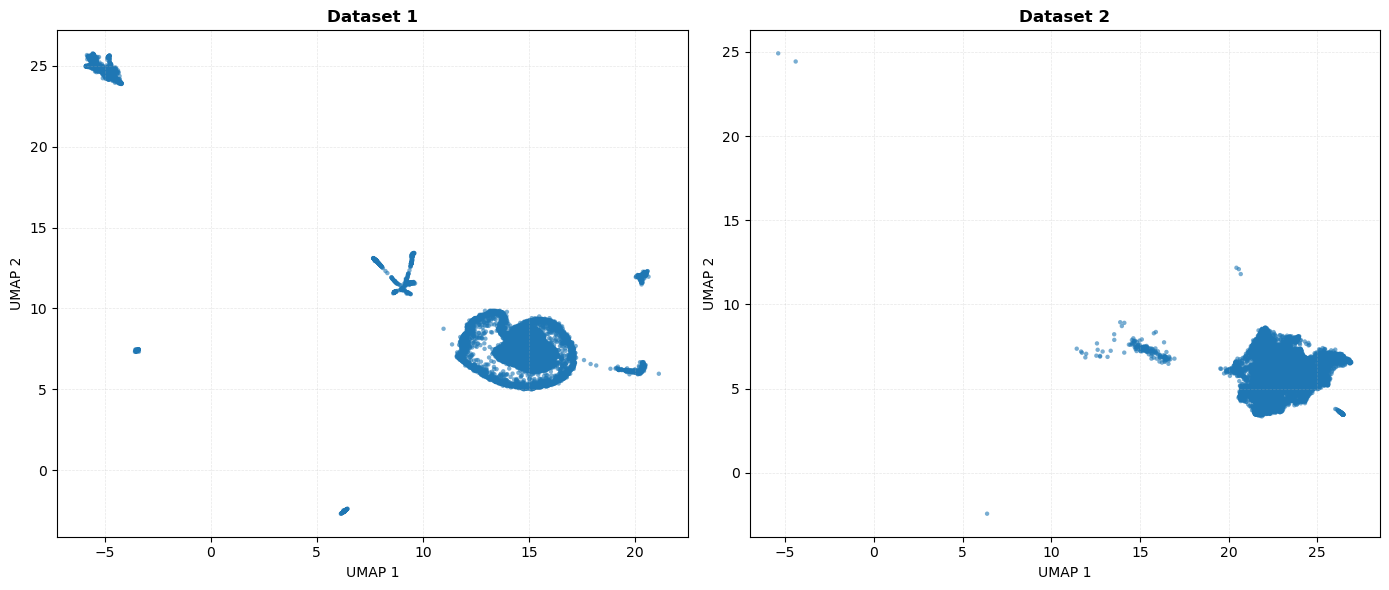

In [22]:
muris_10k = muris.X.toarray()[np.random.choice(muris.n_obs, 10000, replace=False)]
compare_umap([muris_10k, decoded_samples])

Performing UMAP on combined dataset (20000 samples, 128 features) across 2 datasets...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


([array([[-1.7986887, -7.783927 ],
         [ 1.8007358, 13.126312 ],
         [ 1.8592312, -8.438763 ],
         ...,
         [ 3.8679676, -4.5422225],
         [-2.6157894, 17.69136  ],
         [-3.3185596, -4.640818 ]], shape=(10000, 2), dtype=float32),
  array([[-0.39215037,  1.080085  ],
         [-0.9353742 , -1.149584  ],
         [-0.4579636 , -0.43764478],
         ...,
         [-1.324933  , -2.115731  ],
         [ 1.1588968 , -1.890879  ],
         [-1.6916883 , -0.10991043]], shape=(10000, 2), dtype=float32)],
 <Figure size 1400x600 with 2 Axes>)

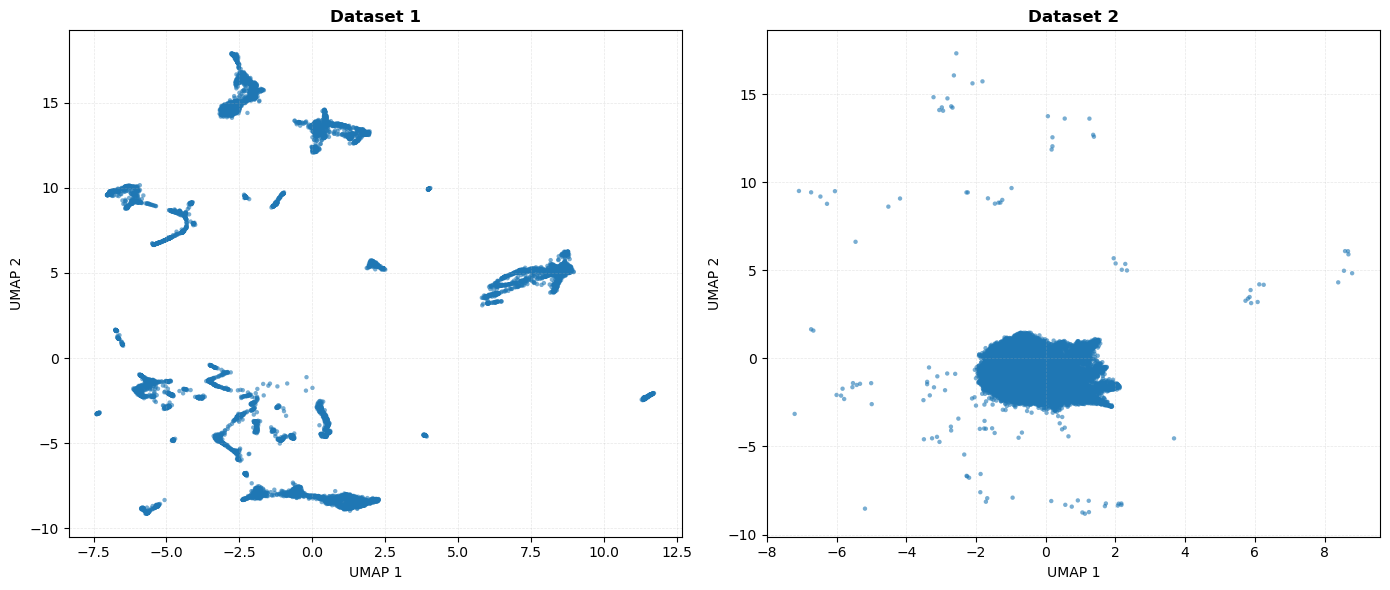

In [23]:
encoded_10k = X_encoded[np.random.choice(X_encoded.shape[0], 10000, replace=False)]
compare_umap([encoded_10k, latent_samples])

Performing UMAP on combined dataset (20000 samples, 18996 features) across 2 datasets...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


([array([[ 4.471026 ,  6.9299526],
         [11.269898 , 12.10718  ],
         [ 8.303164 , -3.9044673],
         ...,
         [ 8.124567 ,  9.9674635],
         [-5.1823735,  2.4050353],
         [13.476627 ,  7.3999486]], shape=(10000, 2), dtype=float32),
  array([[ 13.124833 ,   8.441187 ],
         [ 17.825138 ,  -9.10319  ],
         [  7.802574 ,  -5.947729 ],
         ...,
         [ 12.9817915, -10.618136 ],
         [  8.191948 ,  -6.321712 ],
         [ 13.125711 ,  -4.1373587]], shape=(10000, 2), dtype=float32)],
 <Figure size 1400x600 with 2 Axes>)

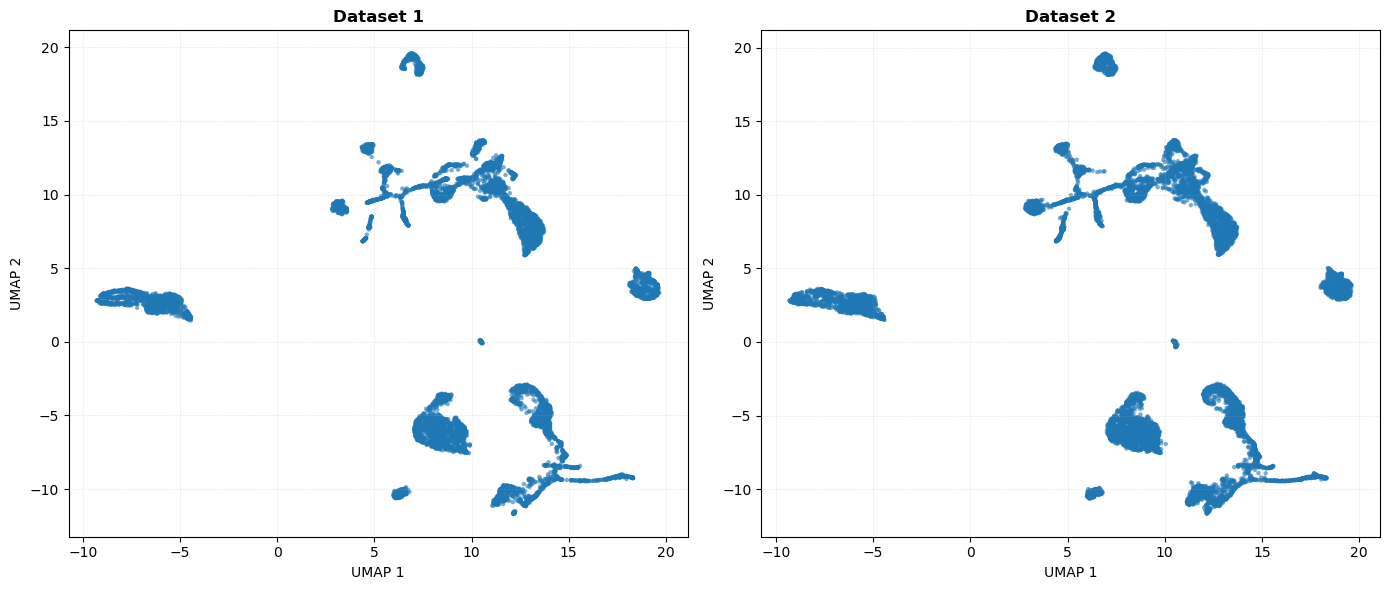

In [24]:
compare_umap([muris_10k, samples_baseline])

## Training with standardized latents
Unconditional diffusion model with standardized latents and 0.8 guidance dropout

In [25]:

standard_scaler = StandardScaler()
scaled_X_encoded = standard_scaler.fit_transform(X_encoded)
scaled_encoded_muris = ad.AnnData(scaled_X_encoded, obs=muris.obs.copy())

scaled_latent_dm = ScDataModule(
    scaled_encoded_muris,
    label_key="celltype",
    encoder="LabelEncoder",
    batch_size=128,
    val_split=0.1,
    balanced_sampling = False,
)

scaled_latent_dm.setup()

dim = encoded_muris.X.shape[1]
num_classes = int(scaled_latent_dm.train_dataset.dataset.classes.max()) + 1

diffusion_standardized = LightningDiffusion(
    input_dim=dim,
    num_classes=num_classes,
    use_ema=True,
    ema_decay=0.999,
    guidance_dropout = 0.8
)

trainer = pl.Trainer(
    max_epochs=200,
    accelerator="auto",
    devices="auto",
    log_every_n_steps=50,
    enable_checkpointing=True,
    logger=True,
    default_root_dir="lightning_logs/muris/diffusion",
)

diffusion_model_path = "checkpoints/muris/standardized_trained_diffusion_model.ckpt"
if os.path.exists(diffusion_model_path):
    diffusion_standardized = LightningDiffusion.load_from_checkpoint(diffusion_model_path)
else:
    trainer.fit(diffusion_standardized, scaled_latent_dm)
    trainer.save_checkpoint(diffusion_model_path)
    
scaled_encoded_10k = scaled_X_encoded[np.random.choice(scaled_X_encoded.shape[0], 10000, replace=False)]

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

Performing UMAP on combined dataset (20000 samples, 128 features) across 2 datasets...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


([array([[ 6.321078 ,  8.410694 ],
         [ 4.0517597, 14.923875 ],
         [ 4.773012 , 13.610539 ],
         ...,
         [ 5.7718945,  6.8503   ],
         [11.358198 ,  6.74065  ],
         [ 0.9099434,  6.8261847]], shape=(10000, 2), dtype=float32),
  array([[ 5.5247    , 10.513257  ],
         [-2.461939  , -0.04956805],
         [ 5.3237844 , 10.408417  ],
         ...,
         [ 4.364411  , 15.008009  ],
         [13.208149  ,  5.716515  ],
         [-8.79415   ,  2.7745333 ]], shape=(10000, 2), dtype=float32)],
 <Figure size 1400x600 with 2 Axes>)

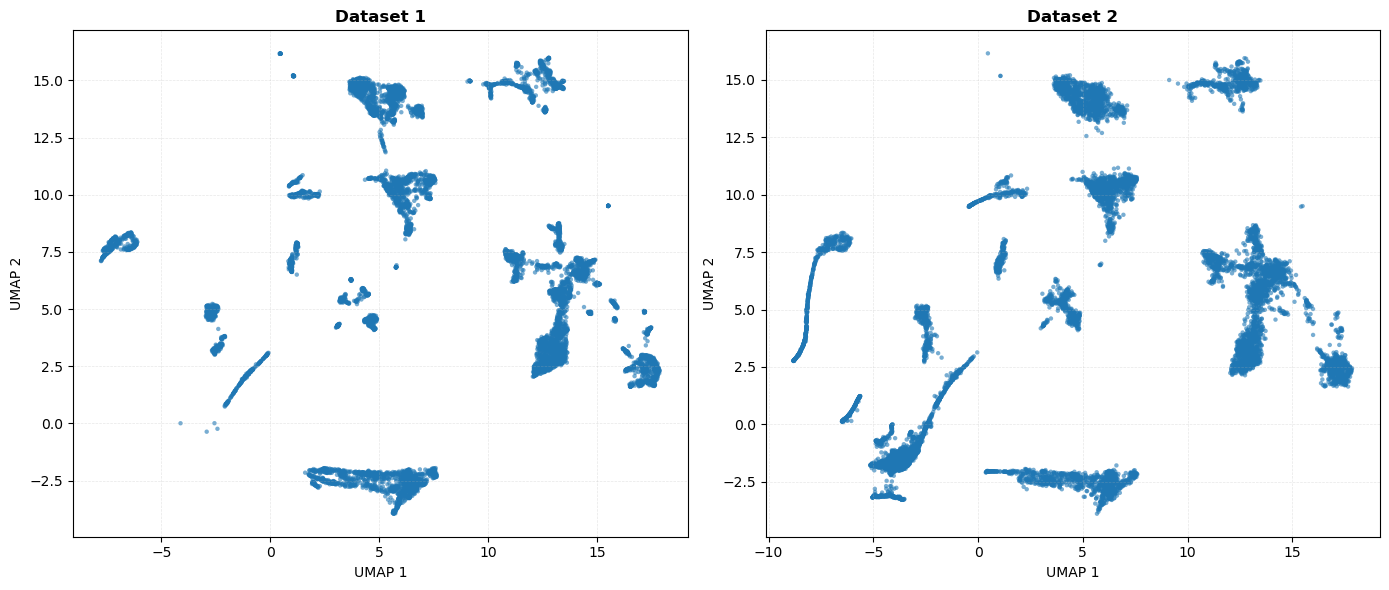

In [26]:
# full ddpm sampling
with torch.no_grad():
    standardized_latent_ddpm_samples = diffusion_standardized.sample(num_samples=10000,
                                                sampling_timesteps=1000,
                                                ddim_sampling_eta=0.1,
                                                use_ema=True,
                                                clip_denoised=False)

compare_umap([scaled_encoded_10k, standardized_latent_ddpm_samples])

In [27]:
diffusion_standardized.eval()
# ddim sampling with cosine time schedule and 100 sampling steps
with torch.no_grad():
    standardized_latent_samples_quadratic = diffusion_standardized.sample(num_samples=10000,
                                      sampling_timesteps=100,
                                      ddim_sampling_eta=0.1,
                                      use_ema=True,
                                      clip_denoised=False,
                                      timestep_schedule="quadratic")
    standardized_latent_samples_linear = diffusion_standardized.sample(num_samples=10000,
                                      sampling_timesteps=100,
                                      ddim_sampling_eta=0.1,
                                      use_ema=True,
                                      clip_denoised=False,
                                      timestep_schedule="linear")
    standardized_latent_samples_cosine = diffusion_standardized.sample(num_samples=10000,
                                      sampling_timesteps=100,
                                      ddim_sampling_eta=0.1,
                                      use_ema=True,
                                      clip_denoised=False,
                                      timestep_schedule="cosine")
    

    

DDIM sampling:   0%|          | 0/97 [00:00<?, ?it/s]

DDIM sampling:   0%|          | 0/100 [00:00<?, ?it/s]

DDIM sampling:   0%|          | 0/99 [00:00<?, ?it/s]

Performing UMAP on combined dataset (50000 samples, 128 features) across 5 datasets...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


([array([[ 3.712176  ,  9.021087  ],
         [ 7.1217084 , 12.202147  ],
         [ 6.321239  , 11.716097  ],
         ...,
         [ 0.83267236,  1.7418969 ],
         [ 3.9822845 ,  2.713262  ],
         [ 1.1819217 ,  5.1571183 ]], shape=(10000, 2), dtype=float32),
  array([[ 4.0570416, 10.39443  ],
         [-4.1056128, -7.459566 ],
         [ 3.8226295, 10.445269 ],
         ...,
         [ 7.09627  , 12.035277 ],
         [ 5.2269783,  2.948234 ],
         [-6.446149 , -2.037538 ]], shape=(10000, 2), dtype=float32),
  array([[-8.373386 , -6.2110233],
         [-7.971031 , -5.7900724],
         [-6.816212 , -9.572832 ],
         ...,
         [-5.3548207, -6.74319  ],
         [-6.432831 , -6.175326 ],
         [-5.8701234, -8.633832 ]], shape=(10000, 2), dtype=float32),
  array([[-10.15788  ,  -4.450365 ],
         [ -5.9348073,  -6.198787 ],
         [ -7.5742073,  -5.6709595],
         ...,
         [ -5.0513387,  -6.597481 ],
         [ -8.116757 ,  -4.579596 ],
         [ -

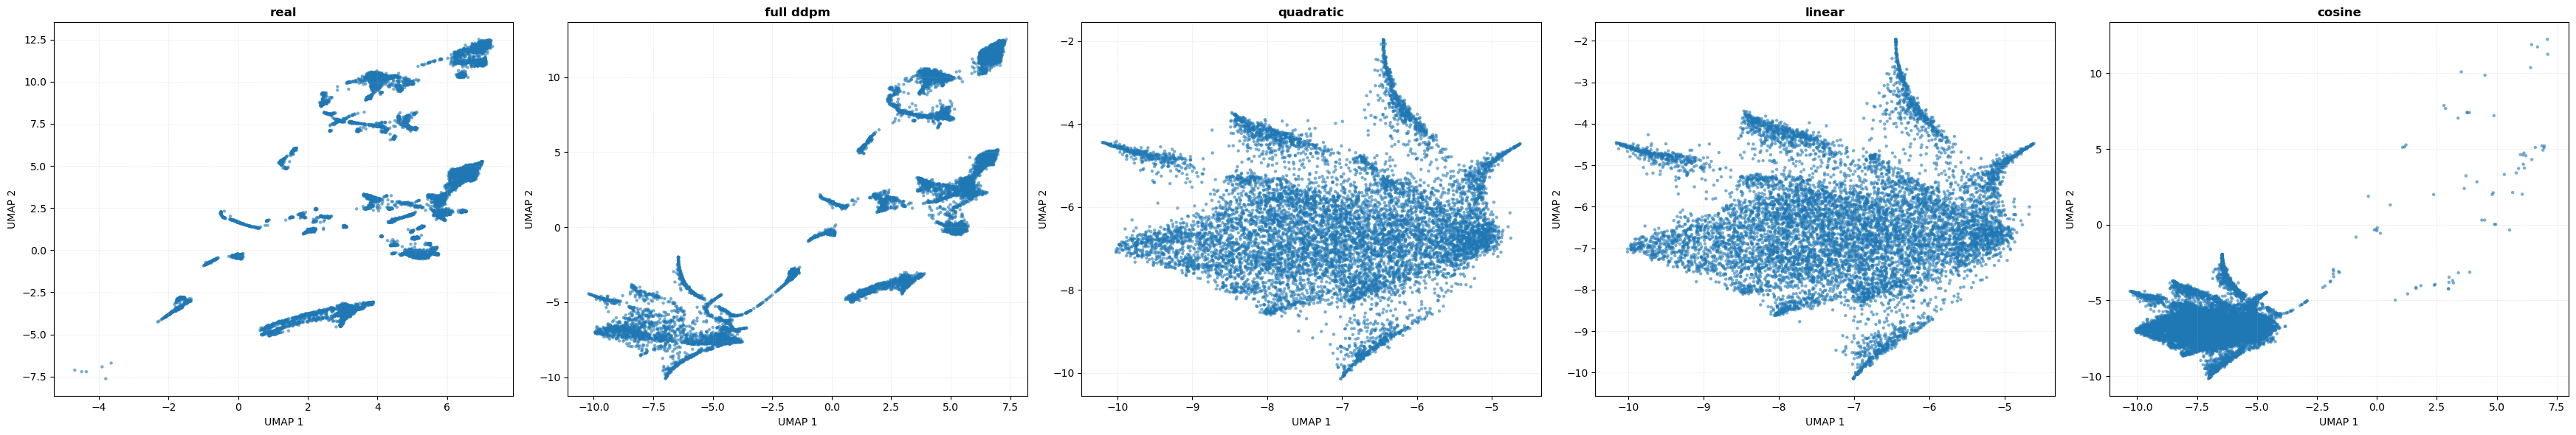

In [28]:
compare_umap([scaled_encoded_10k, 
              standardized_latent_ddpm_samples, 
              standardized_latent_samples_quadratic, 
              standardized_latent_samples_linear, 
              standardized_latent_samples_cosine],
             title_list=["real", "full ddpm", "quadratic", "linear", "cosine"])

Performing UMAP on combined dataset (40000 samples, 128 features) across 4 datasets...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


([array([[ 4.6723933 , 11.348326  ],
         [ 8.425038  , 11.703837  ],
         [ 7.785432  , 11.16855   ],
         ...,
         [ 0.20238052, 11.148109  ],
         [ 0.8689162 ,  7.9200864 ],
         [ 0.78263   , 10.613444  ]], shape=(10000, 2), dtype=float32),
  array([[-4.948214 , 13.018961 ],
         [-4.5186343, 13.023952 ],
         [-5.0133224,  9.993629 ],
         ...,
         [-2.0136807, 11.433245 ],
         [-2.0693903, 13.113249 ],
         [-2.6486635, 13.617794 ]], shape=(10000, 2), dtype=float32),
  array([[-1.1344314, 15.264709 ],
         [-2.5681334, 11.09929  ],
         [-4.365402 , 12.647289 ],
         ...,
         [-2.2176774, 10.63867  ],
         [-3.235216 , 14.953429 ],
         [-3.214662 , 12.14709  ]], shape=(10000, 2), dtype=float32),
  array([[-2.5353506, 11.3048   ],
         [-3.0246549, 15.330963 ],
         [-4.1871877, 11.282645 ],
         ...,
         [-1.7038021, 13.907228 ],
         [-5.7114654, 12.742394 ],
         [-4.761233 , 

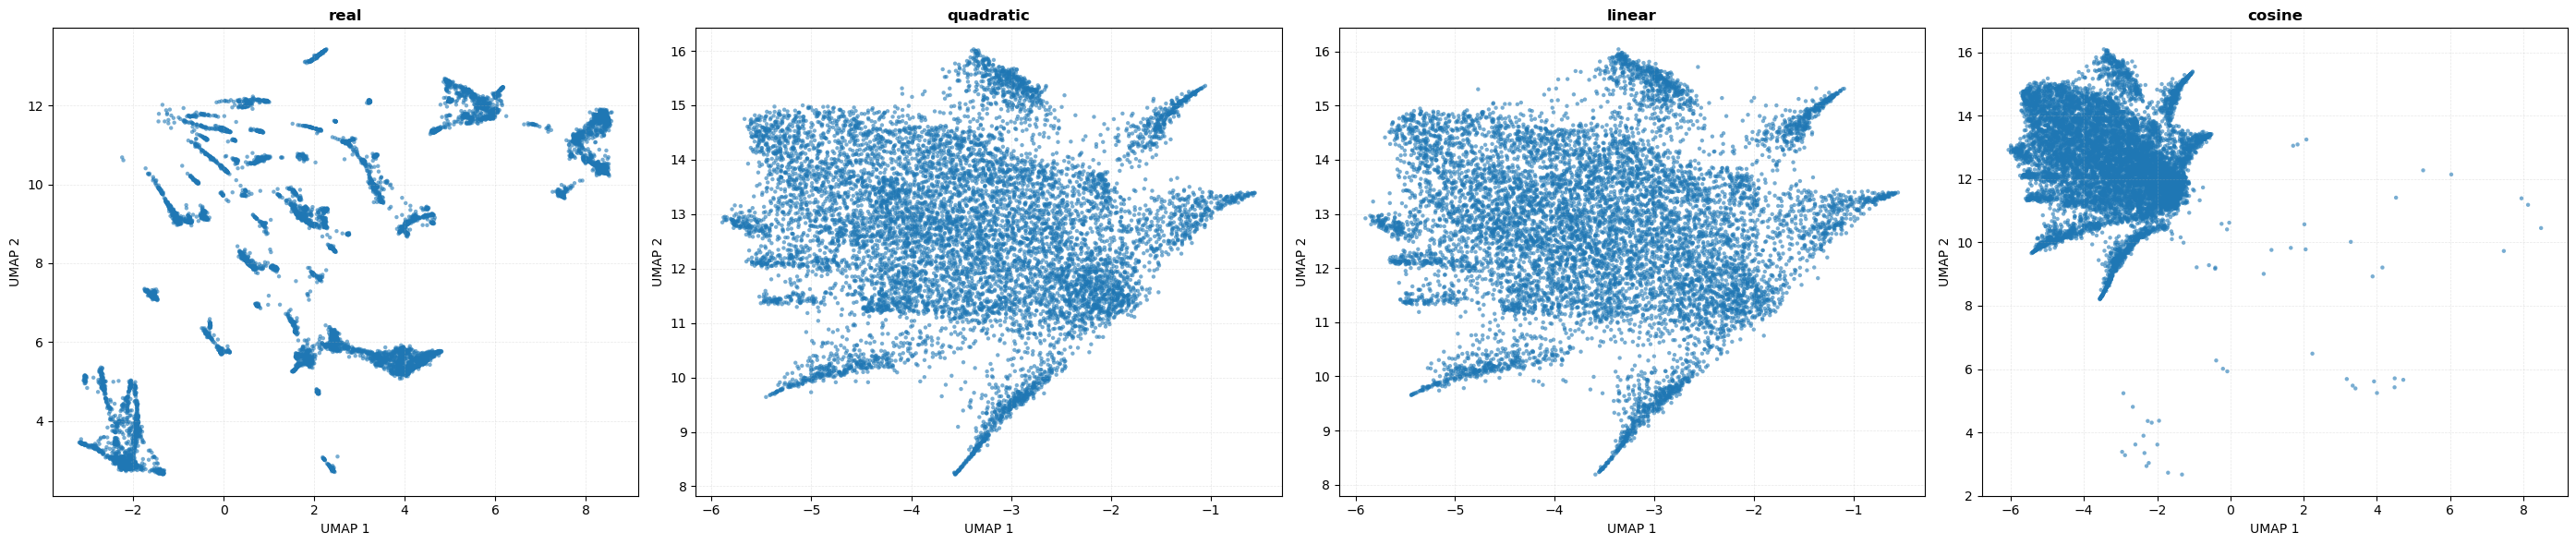

In [29]:
compare_umap([scaled_encoded_10k, standardized_latent_samples_quadratic, standardized_latent_samples_linear, standardized_latent_samples_cosine],
             title_list=["real", "quadratic", "linear", "cosine"])

Performing UMAP on combined dataset (20000 samples, 128 features) across 2 datasets...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...
Performing UMAP on combined dataset (20000 samples, 128 features) across 2 datasets...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...
Performing UMAP on combined dataset (20000 samples, 128 features) across 2 datasets...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


([array([[ 3.1818712e+00,  7.4058285e+00],
         [ 9.2687187e+00,  5.8635120e+00],
         [ 8.0987463e+00,  5.7495785e+00],
         ...,
         [ 5.4934896e-03,  3.9834387e+00],
         [-3.7691503e+00,  1.4149375e+01],
         [-4.8300605e+00,  1.0209541e+01]], shape=(10000, 2), dtype=float32),
  array([[ -8.416365 ,  10.911413 ],
         [-11.3011265,  12.1869545],
         [ -8.916598 ,  12.0123   ],
         ...,
         [ -9.394321 ,  12.737727 ],
         [-10.060122 ,  12.252674 ],
         [-10.303898 ,  11.669941 ]], shape=(10000, 2), dtype=float32)],
 <Figure size 1400x600 with 2 Axes>)

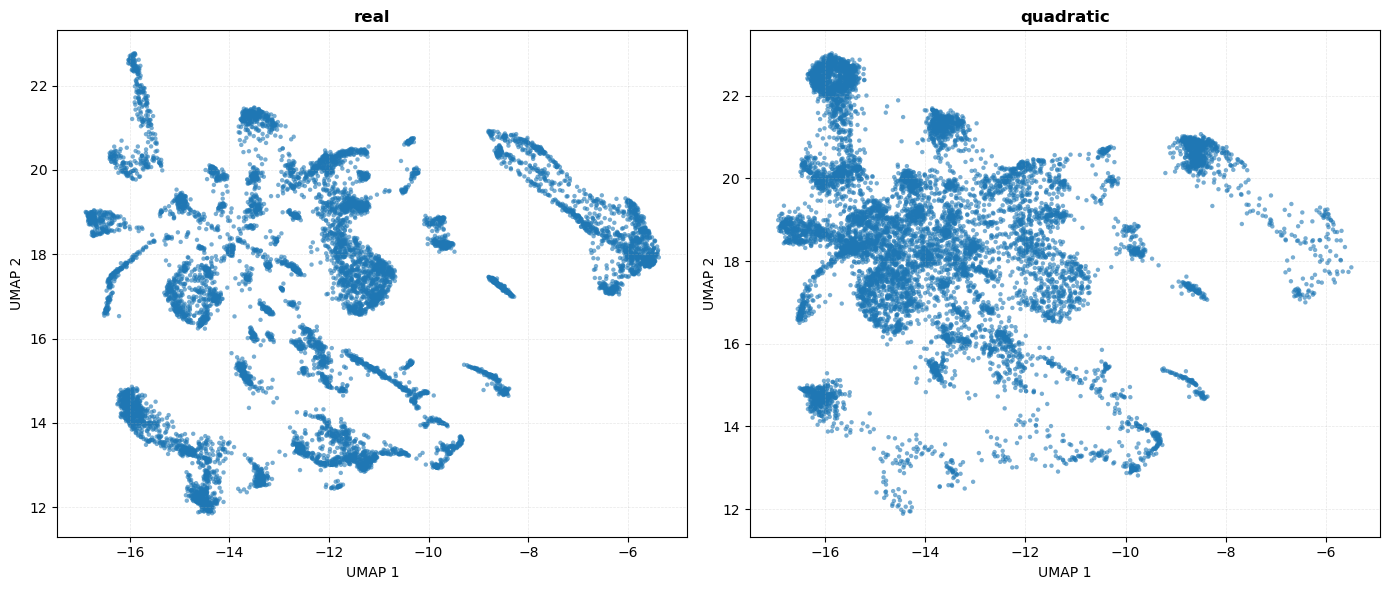

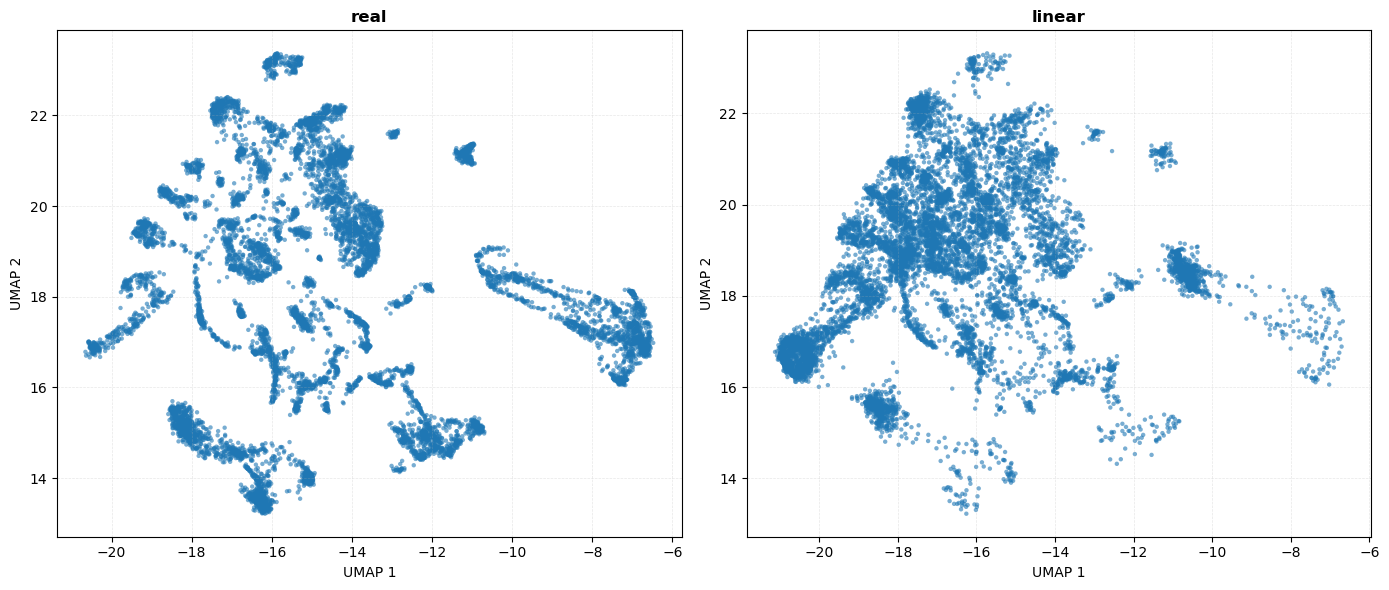

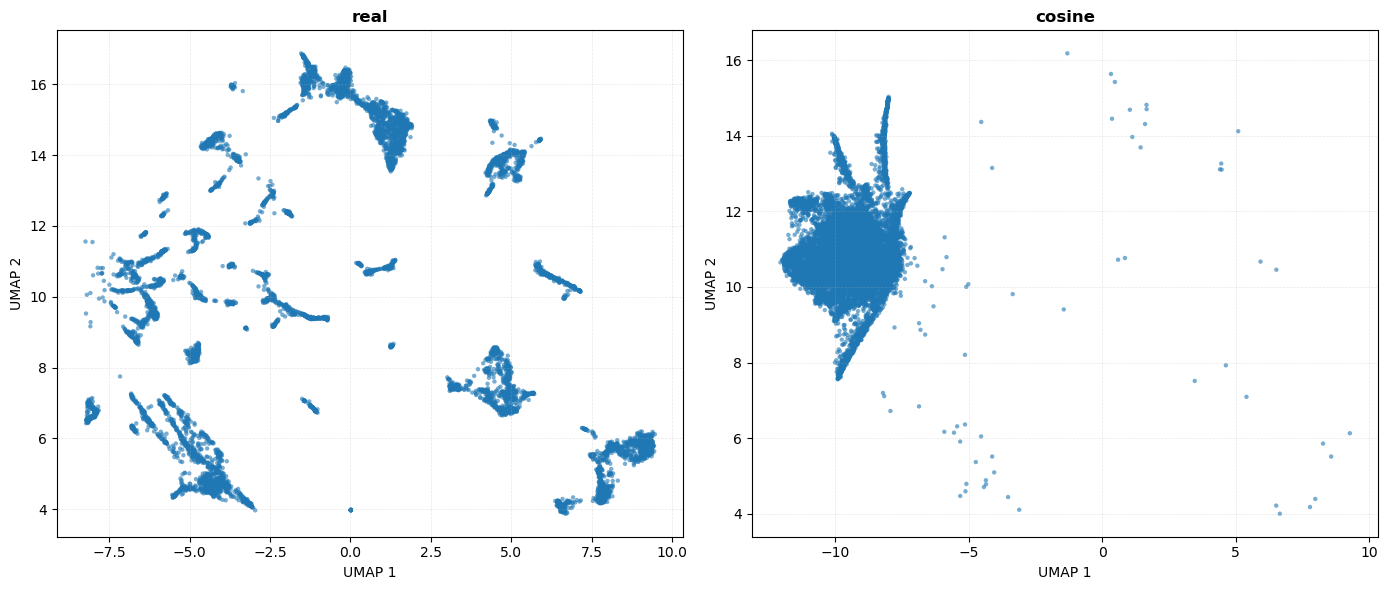

In [30]:
compare_umap([scaled_encoded_10k, standardized_latent_samples_quadratic],
             title_list=["real", "quadratic"])
compare_umap([scaled_encoded_10k, standardized_latent_samples_linear],
             title_list=["real", "linear"])
compare_umap([scaled_encoded_10k, standardized_latent_samples_cosine],
             title_list=["real", "cosine"])


Performing UMAP on combined dataset (30000 samples, 18996 features) across 3 datasets...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


([array([[ 6.2099    , 11.310004  ],
         [ 8.584769  , 13.010027  ],
         [ 9.10956   ,  0.03836098],
         ...,
         [10.940023  , 16.00066   ],
         [-3.9949005 ,  7.7871075 ],
         [ 6.556159  , 17.272886  ]], shape=(10000, 2), dtype=float32),
  array([[12.870008 ,  2.3986328],
         [ 8.170956 , 19.389204 ],
         [13.681959 ,  2.342007 ],
         ...,
         [ 8.666641 , -1.9581368],
         [ 9.745906 , 14.785756 ],
         [ 9.534585 , 21.86501  ]], shape=(10000, 2), dtype=float32),
  array([[ 7.3414564, 16.40782  ],
         [18.498665 ,  3.3009307],
         [ 9.269488 , -2.387092 ],
         ...,
         [18.908989 ,  0.3888092],
         [10.154531 , -1.5235567],
         [12.717968 ,  3.2234528]], shape=(10000, 2), dtype=float32)],
 <Figure size 2100x600 with 3 Axes>)

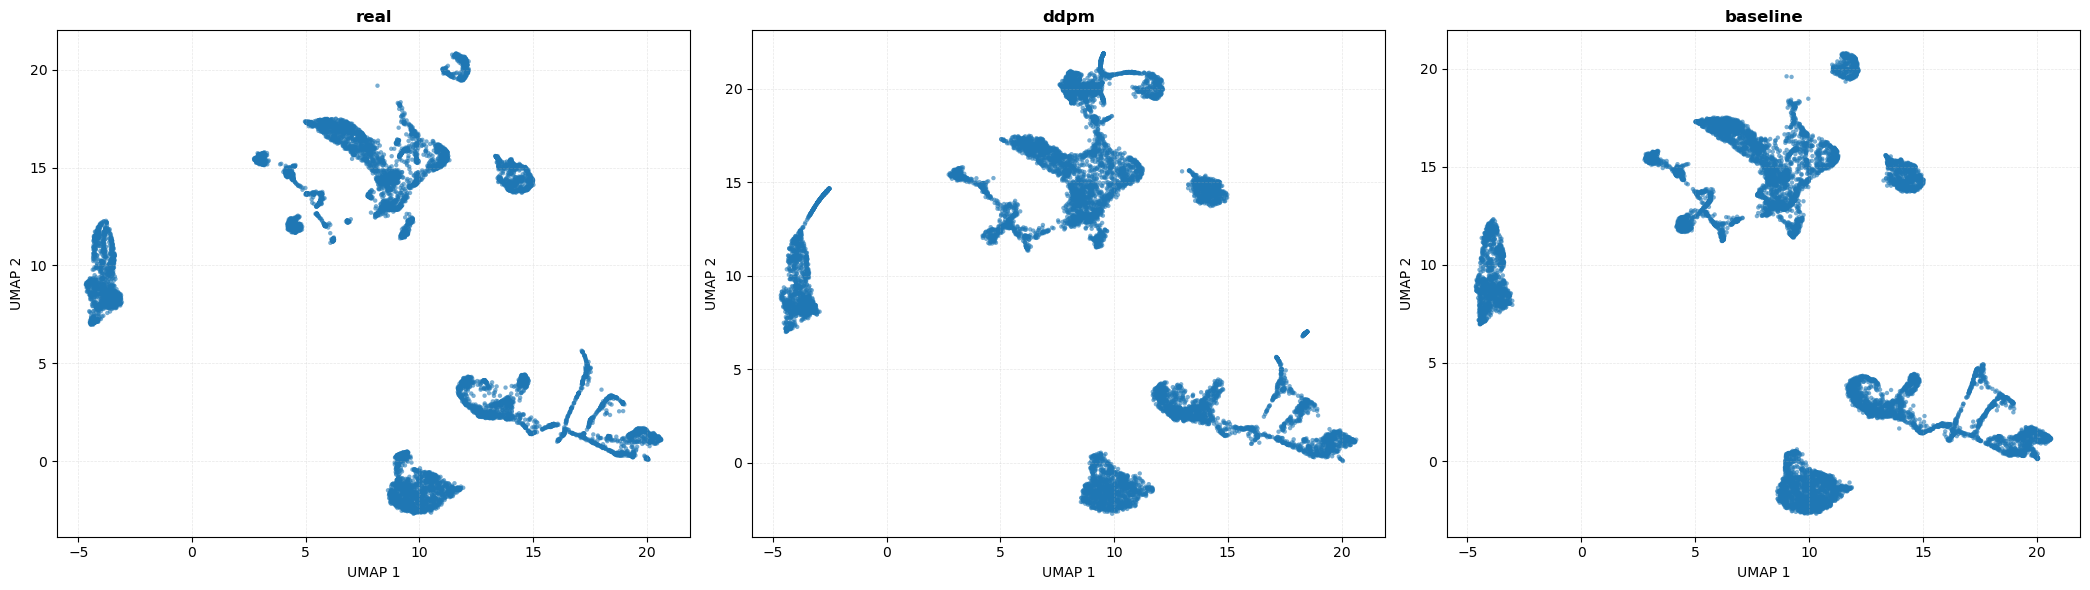

In [31]:
invered_ddpm_samples = standard_scaler.inverse_transform(standardized_latent_ddpm_samples)

with torch.no_grad():
    decoded_ddpm_samples = ae.decode(torch.tensor(invered_ddpm_samples).to(device=device, dtype=torch.float32))
    
compare_umap([muris_10k, decoded_ddpm_samples, samples_baseline],
             title_list=["real", "ddpm", "baseline"])

In [ ]:


with torch.no_grad():
    decoded_cosine_ddim_samples = ae.decode(
        torch.tensor(standard_scaler.inverse_transform(standardized_latent_samples_cosine)).to(device=device, dtype=torch.float32)
    )
    decoded_linear_ddim_samples = ae.decode(
        torch.tensor(standard_scaler.inverse_transform(standardized_latent_samples_linear)).to(device=device, dtype=torch.float32)
    )
    decoded_quadratic_ddim_samples = ae.decode(
        torch.tensor(standard_scaler.inverse_transform(standardized_latent_samples_quadratic)).to(device=device, dtype=torch.float32)
    )
    



In [33]:
muris_samples_path = '../data/samples/muris/'
if not os.path.exists(muris_samples_path):
    os.makedirs(muris_samples_path)

np.save(muris_samples_path + 'decoded_ddpm_samples.npy', decoded_ddpm_samples)
np.save(muris_samples_path + 'decoded_quadratic_ddim_samples.npy', decoded_quadratic_ddim_samples)
np.save(muris_samples_path + 'decoded_linear_ddim_samples.npy', decoded_linear_ddim_samples)
np.save(muris_samples_path + 'decoded_cosine_ddim_samples.npy', decoded_cosine_ddim_samples)